In [1]:
!pip install -q transformers datasets peft accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00


In [2]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
from datasets import load_dataset
dataset = load_dataset("stanfordnlp/imdb")

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/unsupervised-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 42.0MB            

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [5]:
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [6]:
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Format for PyTorch
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [7]:
# Metrics setup
import evaluate
import numpy as np
from transformers import DataCollatorWithPadding

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [8]:
# Train BERT with Full Weight Fine-Tuning
import time
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

In [9]:
!pip install decord
# Or for newer Python/GPU builds if decord has issues:
# pip install eva-decord

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 95.0 MB/s eta 0:00:00


In [10]:
!pip install -U datasets transformers torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.

In [16]:
# Fix sys.modules cache and mock torchvision.io.VideoReader
import sys
import types

# 1. Clean out the broken None entries from memory
sys.modules.pop("torchvision", None)
sys.modules.pop("torchvision.io", None)

# 2. Build lightweight dummy modules directly in sys.modules
mock_tv = types.ModuleType("torchvision")
mock_tv_io = types.ModuleType("torchvision.io")

class DummyVideoReader:
    def __init__(self, *args, **kwargs):
        pass

mock_tv_io.VideoReader = DummyVideoReader
mock_tv.io = mock_tv_io

sys.modules["torchvision"] = mock_tv
sys.modules["torchvision.io"] = mock_tv_io

# 3. Training code
import time
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# Load fresh base model
fft_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)

fft_args = TrainingArguments(
    output_dir="./results_fft",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=torch.cuda.is_available(),
    logging_steps=100
)

fft_trainer = Trainer(
    model=fft_model,
    args=fft_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("=== Starting Full Fine-Tuning ===")
start_time = time.time()
fft_trainer.train()
fft_time = time.time() - start_time

fft_results = fft_trainer.evaluate()
print(f"FFT Training Time: {fft_time:.2f} seconds")
print(f"FFT Accuracy: {fft_results['eval_accuracy'] * 100:.2f}%")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


=== Starting Full Fine-Tuning ===


Epoch,Training Loss,Validation Loss,Accuracy
1,0.227471,0.201510,0.918720
2,0.128589,0.220389,0.923280


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Training Loss,Validation Loss,Epoch,Accuracy
0.128589,0.201457,2,0.918960


FFT Training Time: 884.49 seconds
FFT Accuracy: 91.90%


In [19]:
# Cell 5: Train BERT with Standard LoRA (r=4, alpha=8)
from peft import LoraConfig, get_peft_model, TaskType

# Load clean base model
lora_base_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)

# Configure LoRA: r=4, alpha=8 (Scaling factor = alpha / r = 2x)
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=4,
    lora_alpha=8,
    lora_dropout=0.1,
    target_modules=["query", "value"]  # Applied to self-attention Q and V
)

lora_model = get_peft_model(lora_base_model, lora_config)
lora_model.print_trainable_parameters()

lora_args = TrainingArguments(
    output_dir="./results_lora",
    learning_rate=1e-3,  # Higher LR suitable for PEFT adapters
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=torch.cuda.is_available(),
    logging_steps=100
)

lora_trainer = Trainer(
    model=lora_model,
    args=lora_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("=== Starting LoRA Training ===")
start_time = time.time()
lora_trainer.train()
lora_time = time.time() - start_time

lora_results = lora_trainer.evaluate()
print(f"LoRA Training Time: {lora_time:.2f} seconds")
print(f"LoRA Accuracy: {lora_results['eval_accuracy'] * 100:.2f}%")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 148,994 || all params: 109,632,772 || trainable%: 0.1359
=== Starting LoRA Training ===


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy
1,0.247125,0.222990,0.911040
2,0.190643,0.215101,0.916560


Training Loss,Validation Loss,Epoch,Accuracy
0.190643,0.215101,2,0.916560


LoRA Training Time: 781.90 seconds
LoRA Accuracy: 91.66%


In [18]:
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [21]:
# Cell 7 (Modified): Save models and calculate disk checkpoint sizes (FFT and LoRA only)
import os

# Save models/adapters locally
fft_model.save_pretrained("./saved_fft_model")
lora_model.save_pretrained("./saved_lora_model")

def get_dir_size_mb(path):
    total_bytes = 0
    for root, dirs, files in os.walk(path):
        for f in files:
            fp = os.path.join(root, f)
            total_bytes += os.path.getsize(fp)
    return total_bytes / (1024 * 1024)

fft_size = get_dir_size_mb('./saved_fft_model')
lora_size = get_dir_size_mb('./saved_lora_model')

print("--- Checkpoint Size on Disk ---")
print(f"Full Fine-Tuning Checkpoint : {fft_size:.2f} MB")
print(f"LoRA Adapter Checkpoint     : {lora_size:.2f} MB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

--- Checkpoint Size on Disk ---
Full Fine-Tuning Checkpoint : 417.67 MB
LoRA Adapter Checkpoint     : 0.58 MB


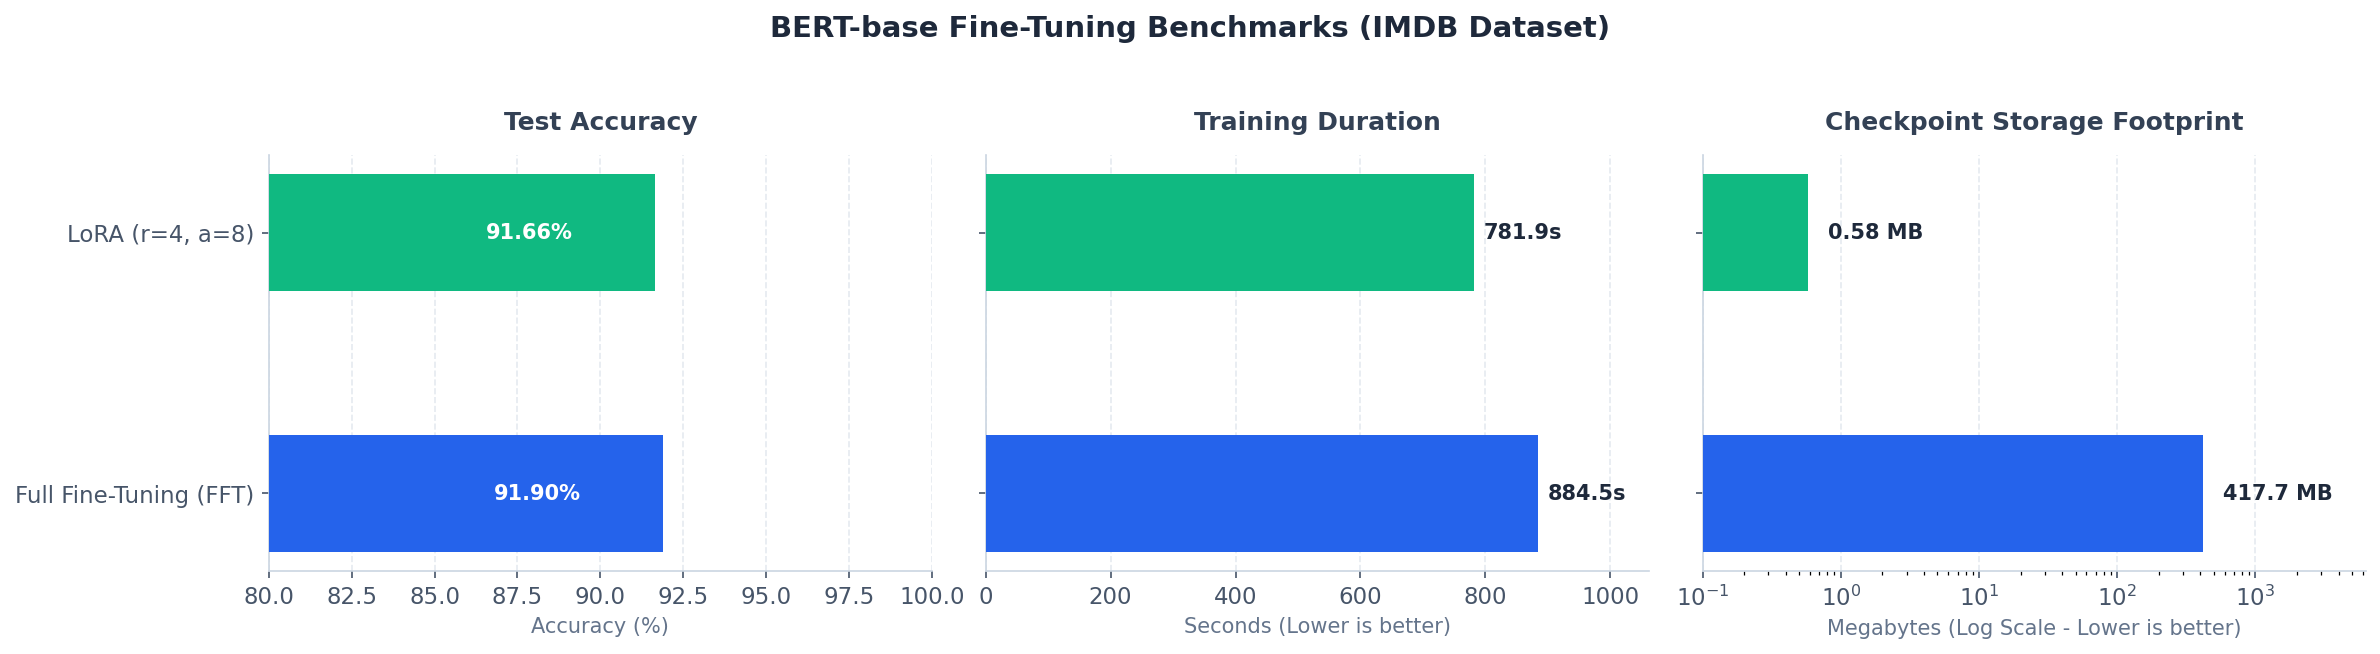

In [24]:
# Cell 8: Professional Comparison Visualization
import matplotlib.pyplot as plt
import pandas as pd

# Set global modern aesthetic
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.edgecolor': '#E0E0E0',
    'axes.linewidth': 0.8
})

models = df["Model"].tolist()
colors = ['#2563EB', '#10B981']  # Modern Indigo / Emerald

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), dpi=150)
fig.suptitle('BERT-base Fine-Tuning Benchmarks (IMDB Dataset)',
             fontsize=14, fontweight='bold', color='#1E293B', y=1.03)

# 1. Test Accuracy
acc_values = df["Accuracy (%)"]
bars1 = axes[0].barh(models, acc_values, color=colors, height=0.45, zorder=3)
axes[0].set_title('Test Accuracy', fontsize=12, fontweight='600', pad=12, color='#334155')
axes[0].set_xlim(80, 100)
axes[0].set_xlabel('Accuracy (%)', fontsize=10, color='#64748B')
for bar in bars1:
    width = bar.get_width()
    axes[0].text(width - 2.5, bar.get_y() + bar.get_height()/2, f'{width:.2f}%',
                 va='center', ha='right', color='white', fontweight='bold', fontsize=10)

# 2. Training Time
time_values = df["Training Time (s)"]
bars2 = axes[1].barh(models, time_values, color=colors, height=0.45, zorder=3)
axes[1].set_title('Training Duration', fontsize=12, fontweight='600', pad=12, color='#334155')
axes[1].set_xlabel('Seconds (Lower is better)', fontsize=10, color='#64748B')
axes[1].set_yticklabels([])  # Hide duplicate y-labels
for bar in bars2:
    width = bar.get_width()
    axes[1].text(width + 15, bar.get_y() + bar.get_height()/2, f'{width:.1f}s',
                 va='center', ha='left', color='#1E293B', fontweight='600', fontsize=10)
axes[1].set_xlim(0, max(time_values) * 1.2)

# 3. Checkpoint Disk Size (Log Scale)
size_values = df["Checkpoint Size (MB)"]
bars3 = axes[2].barh(models, size_values, color=colors, height=0.45, zorder=3)
axes[2].set_title('Checkpoint Storage Footprint', fontsize=12, fontweight='600', pad=12, color='#334155')
axes[2].set_xscale('log')
axes[2].set_xlabel('Megabytes (Log Scale - Lower is better)', fontsize=10, color='#64748B')
axes[2].set_yticklabels([])  # Hide duplicate y-labels
for bar in bars3:
    width = bar.get_width()
    val_str = f'{width:.2f} MB' if width < 10 else f'{width:.1f} MB'
    axes[2].text(width * 1.4, bar.get_y() + bar.get_height()/2, val_str,
                 va='center', ha='left', color='#1E293B', fontweight='600', fontsize=10)
axes[2].set_xlim(0.1, max(size_values) * 15)

# Styling cleanups across all subplots
for ax in axes:
    ax.grid(axis='x', linestyle='--', alpha=0.5, color='#CBD5E1', zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CBD5E1')
    ax.spines['bottom'].set_color('#CBD5E1')
    ax.tick_params(colors='#475569')

plt.tight_layout()
plt.show()